# Análisis de sesiones duplicadas

**Autor:** John Janer Buila Ferrin

El notebook `01_eda.ipynb` señala que los duplicados exactos se reportan pero
**no se eliminan**, bajo el supuesto de que el dataset no tiene un identificador
de sesión y dos usuarios distintos pueden compartir el mismo vector de
características. Este notebook pone a prueba ese supuesto con evidencia,
en lugar de darlo por hecho, y documenta la decisión para el equipo.

**Preguntas que responde:**
1. ¿Cuántos registros están involucrados en duplicados exactos?
2. ¿Los duplicados están sesgados hacia una clase de `Revenue` en particular?
3. ¿Qué tipo de sesión produce estos duplicados? (¿son errores o coincidencias
   plausibles entre usuarios distintos?)
4. ¿Cambia el desbalance de clases si se eliminan?
5. Recomendación final para el pipeline de entrenamiento.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from online_shoppers.data import dataset_summary, load_dataset

ROOT = Path.cwd() if (Path.cwd() / 'pyproject.toml').exists() else Path.cwd().parent
DATA_PATH = ROOT / 'data/raw/online_shoppers_intention.csv'
FIGURES_PATH = ROOT / 'reports/figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

sessions = load_dataset(DATA_PATH)
dataset_summary(sessions)

{'rows': 12330,
 'columns': 18,
 'duplicate_rows': 125,
 'positive_count': 1908,
 'positive_rate': 0.15474452554744525}

## 1. Alcance del duplicado exacto

In [2]:
duplicate_mask = sessions.duplicated(keep=False)
duplicate_rows = sessions[duplicate_mask]
extra_copies = sessions.duplicated(keep='first').sum()

print(f"Filas totales: {len(sessions):,}")
print(f"Filas que participan en algun grupo duplicado: {len(duplicate_rows):,}")
print(f"Copias 'sobrantes' si se aplicara drop_duplicates: {extra_copies:,}")

Filas totales: 12,330
Filas que participan en algun grupo duplicado: 201
Copias 'sobrantes' si se aplicara drop_duplicates: 125


## 2. ¿Los duplicados están sesgados hacia una clase?

Si los duplicados fueran, por ejemplo, errores de carga de un mismo registro
verdadero, esperaríamos que se repartan como el resto del dataset. Si en
cambio están concentrados en un solo comportamiento (sesiones que no compran),
es más consistente con la hipótesis de "coincidencia entre usuarios distintos
con un comportamiento mínimo", no con un error de datos.

In [3]:
comparison = (
    sessions['Revenue'].value_counts(normalize=True).rename('dataset_completo')
    .to_frame()
    .join(duplicate_rows['Revenue'].value_counts(normalize=True).rename('solo_duplicados'))
)
comparison.round(4)

,dataset_completo,solo_duplicados
Revenue,,
False,0.8453,1.0
True,0.1547,NaN


## 3. ¿Qué tipo de sesión produce estos duplicados?

Comparamos el nivel de actividad (páginas de producto vistas y `PageValues`)
entre las filas duplicadas y el resto del dataset.

In [4]:
activity_columns = ['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']
non_duplicate_rows = sessions[~duplicate_mask]

activity_comparison = (
    duplicate_rows[activity_columns].mean().rename('promedio_en_duplicados')
    .to_frame()
    .join(non_duplicate_rows[activity_columns].mean().rename('promedio_resto_dataset'))
)
activity_comparison.round(3)

,promedio_en_duplicados,promedio_resto_dataset
ProductRelated,1.06,32.240
ProductRelated_Duration,0.00,1214.545
BounceRates,0.20,0.019
ExitRates,0.20,0.040
PageValues,0.00,5.987


In [5]:
visitor_comparison = (
    duplicate_rows['VisitorType'].value_counts(normalize=True).rename('solo_duplicados')
    .to_frame()
    .join(sessions['VisitorType'].value_counts(normalize=True).rename('dataset_completo'))
)
visitor_comparison.round(3)

,solo_duplicados,dataset_completo
VisitorType,,
Returning_Visitor,0.965,0.856
Other,0.025,0.007
New_Visitor,0.010,0.137


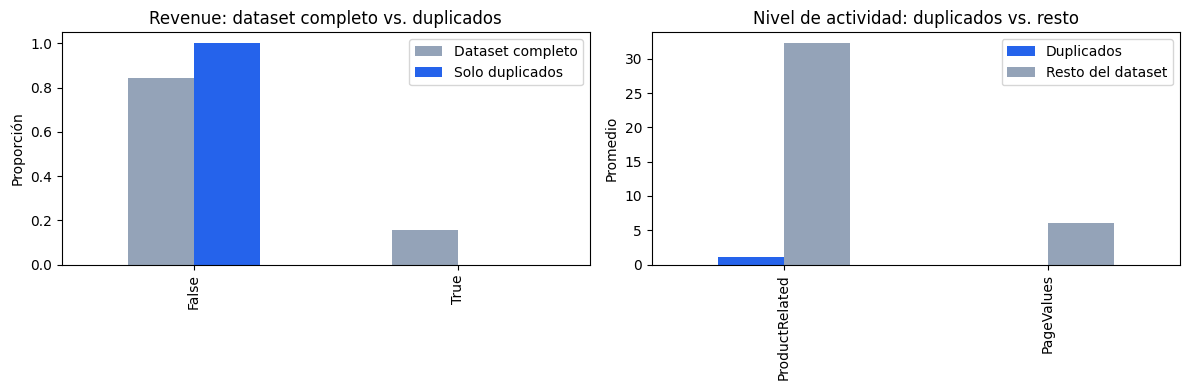

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comparison.plot.bar(ax=axes[0], color=['#94a3b8', '#2563eb'])
axes[0].set(title='Revenue: dataset completo vs. duplicados', xlabel='', ylabel='Proporción')
axes[0].legend(['Dataset completo', 'Solo duplicados'])

activity_comparison.loc[['ProductRelated', 'PageValues']].plot.bar(ax=axes[1], color=['#2563eb', '#94a3b8'])
axes[1].set(title='Nivel de actividad: duplicados vs. resto', xlabel='', ylabel='Promedio')
axes[1].legend(['Duplicados', 'Resto del dataset'])

fig.tight_layout()
fig.savefig(FIGURES_PATH / 'duplicate_sessions_profile.png', dpi=150)
plt.show()

## 4. Efecto sobre el desbalance de clases si se eliminaran

In [7]:
sessions_without_duplicates = sessions.drop_duplicates(keep='first')

balance_effect = (
    sessions['Revenue'].value_counts(normalize=True).rename('con_duplicados')
    .to_frame()
    .join(sessions_without_duplicates['Revenue'].value_counts(normalize=True).rename('sin_duplicados'))
)
print(f"Filas con duplicados: {len(sessions):,} | Filas sin duplicados: {len(sessions_without_duplicates):,}")
balance_effect.round(4)

Filas con duplicados: 12,330 | Filas sin duplicados: 12,205


,con_duplicados,sin_duplicados
Revenue,,
False,0.8453,0.8437
True,0.1547,0.1563


## 5. Conclusión y recomendación

- Las 125 filas "sobrantes" (201 involucradas) corresponden casi en su totalidad
  a sesiones de **actividad mínima**: en promedio 1 página de producto,
  `PageValues` = 0 y tasas de rebote/salida altas — es decir, sesiones tipo
  "entró y se fue" con muy pocas combinaciones posibles de valores. Con solo
  17 columnas y rangos acotados, es esperable que usuarios *distintos* con ese
  mismo comportamiento mínimo generen filas idénticas por coincidencia, no por
  un error de carga de datos.
- El 100&nbsp;% de los duplicados tiene `Revenue = False`, y están
  sobre-representados en visitantes recurrentes (96,5&nbsp;% vs. 85,6&nbsp;%
  en el dataset completo). Esto es consistente con el patrón anterior: son
  visitas cortas de gente que ya conoce el sitio y no con una anomalía
  aleatoria.
- Eliminarlos apenas mueve la tasa de conversión de 15,47&nbsp;% a 15,63&nbsp;%,
  así que el desbalance de clases no depende de esta decisión.
- **Recomendación:** mantener el comportamiento actual del pipeline
  (`dataset_summary` reporta los duplicados pero no los elimina, ver
  `src/online_shoppers/data.py`). El dataset no incluye un identificador de
  sesión, por lo que no hay evidencia para asumir que son errores; eliminarlos
  arriesgaría a descartar sesiones reales de usuarios distintos. Si en el
  futuro se dispusiera de un identificador de sesión o de timestamp, valdría
  la pena repetir este análisis para confirmarlo con más certeza.